 ## Importing the Libraries ##

In [525]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense , Flatten
from keras.layers import Conv2D,MaxPooling2D,Dropout
from keras.utils import to_categorical

In [526]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2944960262118674701
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 9460032963106845525
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


**Loading the dataset**

In [527]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [528]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


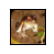

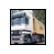

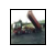

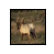

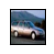

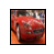

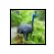

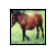

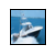

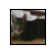

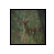

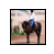

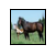

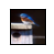

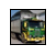

In [529]:
import matplotlib.pyplot as plt
n = 15
for i in range(n):
  plt.figure(figsize=(8,6))
  ax = plt.subplot(1,n,i+1)
  plt.imshow(X_train[i].reshape(32,32,3))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()
plt.close()


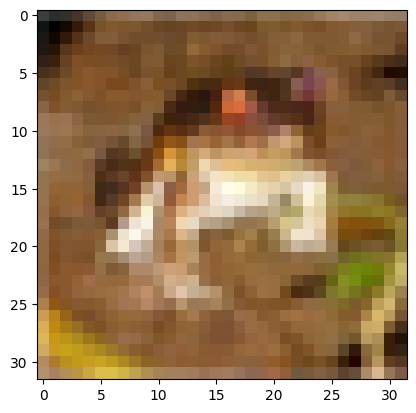

In [530]:
plt.imshow(X_train[0].reshape(32,32,3))


In [531]:
y_train[:3]

array([[6],
       [9],
       [9]], dtype=uint8)

In [532]:
y_train = y_train.reshape(-1,)
y_train[:3]

array([6, 9, 9], dtype=uint8)

In [533]:
y_train.shape

(50000,)

In [534]:
y_test.shape

(10000, 1)

In [535]:
y_test[:3]

array([[3],
       [8],
       [8]], dtype=uint8)

In [536]:
y_test = y_test.reshape(-1,)
y_test[:3]

array([3, 8, 8], dtype=uint8)

In [537]:
classes_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
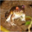

In [538]:
X_train[0]

In [539]:
def plot_sample(X,y,index):
  plt.figure(figsize=(8,6))
  plt.imshow(X[index])
  plt.xlabel(classes_names[y[index]])

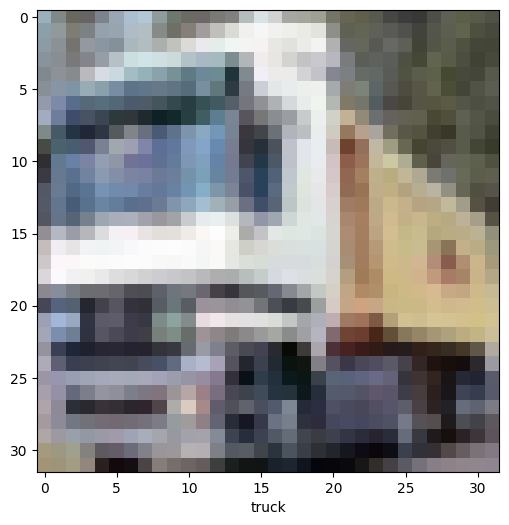

In [540]:
plot_sample(X_train,y_train,1)

In [541]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000,)
(10000,)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
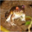

In [542]:
X_train[0]

In [543]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train/255
X_test = X_test/255

In [544]:
num_classes = 10

In [545]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

# Buliding the CNN Model #

In [546]:
img_row,img_col,channel = 32,32,3
filter = [32,64,128,256]


In [547]:
model = Sequential()
model.add(Conv2D(filter[0],(3,3),activation='relu',padding='same',input_shape=(img_row,img_col,channel)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filter[1],(3,3),activation='relu',padding='same'))

model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filter[2],(2,2),activation='relu',padding='same'))

model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filter[3],(2,2),activation='relu',padding='same'))

model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Flatten())
model.add(Dense(64,activation='relu'))

model.add(Dense(num_classes,activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [548]:
model.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_178 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_174               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_179 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_175               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_180 (Conv2D)             │ (None, 8, 8, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_176               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_181 (Conv2D)             │ (None, 4, 4, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_177               │ (None, 2, 2, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_51 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,866 (976.04 KB)

 Trainable params: 249,866 (976.04 KB)

 Non-trainable params: 0 (0.00 B)

In [549]:
from time import time
start = time()
model.fit(X_train,y_train,batch_size = 264,epochs=30,verbose=1)
end = time()

print(f' total time taken by the model is {end-start} sec ')

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3695 - loss: 1.7253
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5096 - loss: 1.3479
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5846 - loss: 1.1660
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6281 - loss: 1.0544
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6653 - loss: 0.9493
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6897 - loss: 0.8796
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7142 - loss: 0.8212
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7338 - loss: 0.7625
Epoch 9/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7541 - loss: 0.7088
Epoch 10/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7663 - loss: 0.6708
Epoch 11/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7839 - loss: 0.6231
Epoch 12/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 

In [550]:
y_test.shape

(10000, 10)

In [551]:
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test,verbose=0)
y_pred = np.where(y_pred_prob>0.5,1,0)


test_accuracy = accuracy_score(y_pred,y_test)

print(f'accuracy score is {test_accuracy}')

accuracy score is 0.7233


In [552]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [553]:
y_test = y_test.reshape(-1,)
y_test

array([0., 0., 0., ..., 1., 0., 0.])

In [554]:
X_sample = X_test[:10]

y_pred_prob_sample = model.predict(X_sample,verbose=0)
y_pred_sample = np.where(y_pred_prob_sample>0.5,1,0)

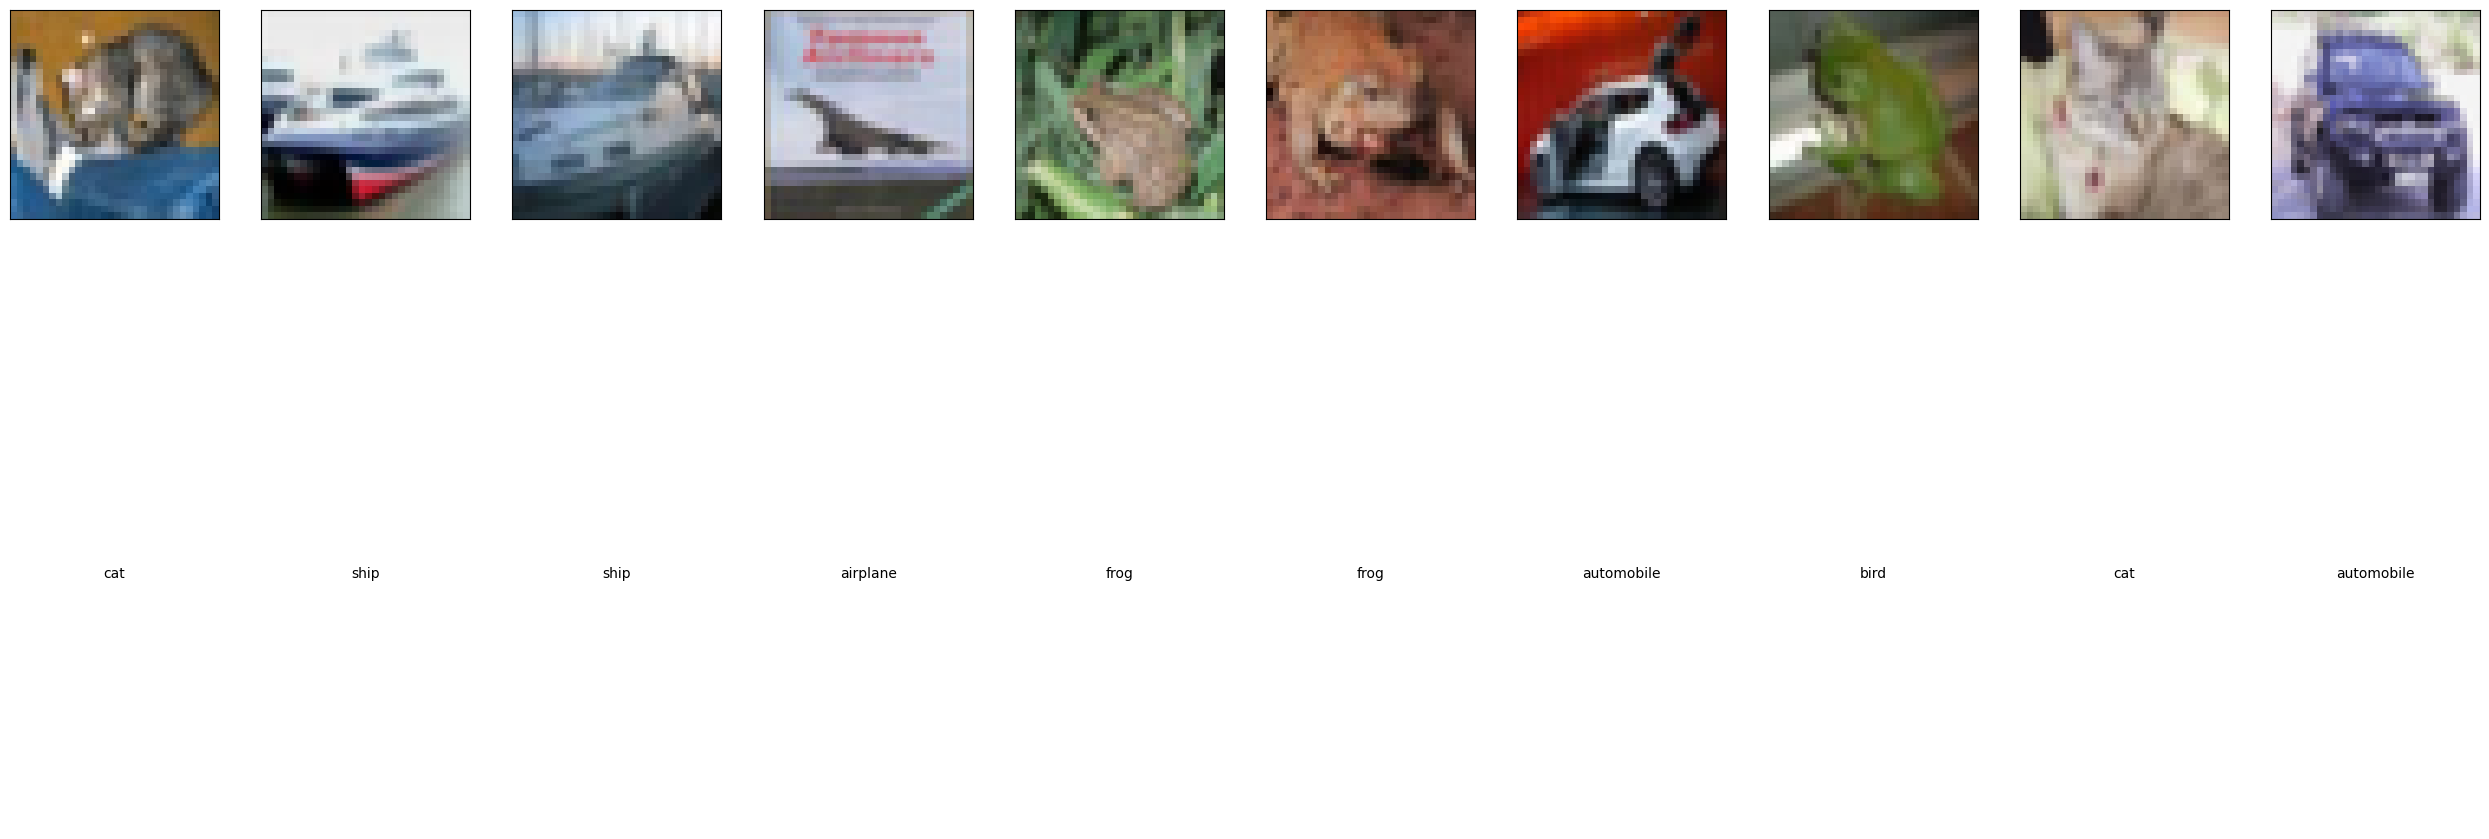

In [555]:

mask = range(20,50)


n = len(X_sample)

plt.figure(figsize=(25,10))



for i in range(len(X_sample)):
  ax = plt.subplot(2,n,i+1)
  plt.subplots_adjust(hspace=0.6, wspace=0.3)
  plt.imshow(X_sample[i].reshape(32,32,3))
  plt.tight_layout()
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)



  predicted_image = np.argmax(y_pred_prob_sample[i])
  fontsize = 10
  x,y = 0.5,0.5
  if predicted_image == 0:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[0]),fontsize=fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 1:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[1]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 2:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[2]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 3:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[3]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 4:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[4]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 5:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[5]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 6:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[6]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 7:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[7]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 8:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[8]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')
  elif predicted_image == 9:
    ax = plt.subplot(2,n,i +1 +n)
    plt.text(x,y,str(classes_names[9]),fontsize = fontsize,ha='center', va = 'center')
    plt.axis('off')


plt.show()

plt.close()


In [556]:
model.save("cifar10_model.h5")

In [561]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

model = load_model("cifar10_model.h5")

img = image.load_img("/content/frog.jpg", target_size=(32,32,3))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("The image you enter is a :", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
The image you enter is a : frog
